# CSBP441 Lab 3: Fully Connected NN versus CNN

## Lab assignment: a controlled experiment on 50 ImageNet images

**Applied Computer Vision | UAE University**

[Open in Google Colab](https://colab.research.google.com/github/MoyoG/CSBP441/blob/main/docs/notebooks/Lab3_NN_vs_CNN_ImageNet_50.ipynb)

This notebook compares two image classifiers trained on exactly the same data:

1. A **fully connected neural network (NN)** that flattens every image.
2. A **convolutional neural network (CNN)** that preserves spatial structure and
   shares kernel weights across image positions.

The dataset is **Imagenette**, a 10-class subset of ImageNet. We select exactly
50 images from each class, giving **500 images total**.

> This is a teaching experiment, not a benchmark. The test set contains only
> 50 images, so one image changes test accuracy by 2 percentage points.

Restart the Colab runtime and run all cells before recording results. Saved outputs
in this file may come from an earlier 100-image run.

### Learning outcomes

By the end, you should be able to:

- explain what flattening removes from an image representation;
- compare dense connections with local convolutional connections;
- calculate and compare model parameter counts;
- recognize overfitting in training and validation curves;
- compare clean-image and shifted-image performance;
- inspect CNN feature maps and explain what convolution learns.


## 1. Why Imagenette?

[Imagenette](https://github.com/fastai/imagenette) contains ten easily
classified ImageNet categories: tench, English springer, cassette player,
chain saw, church, French horn, garbage truck, gas pump, golf ball, and
parachute. The official 160-pixel version is about 94 MB, making it practical
for a Colab class exercise.

The complete dataset is much larger than 500 images. This notebook downloads
the official data, then uses a fixed random seed to select 50 images per class.


## 2. Experimental controls

To make the comparison meaningful, both models use:

- the same 500 selected images;
- the same 70/20/10 train, validation, and test split;
- the same `64 x 64` RGB inputs;
- the same augmentation operations;
- the same optimizer, learning rate, loss, batch size, and stopping rule.

Only the architecture changes.

The models are intentionally **not parameter-matched**. Parameter efficiency is
one of the properties being studied: the dense model's parameter count grows
rapidly because flattening creates a separate connection from every pixel.

| Model | Image representation | Main assumption |
|---|---|---|
| Fully connected NN | Flatten `H x W x C` into one vector | Every pixel position needs separate weights |
| CNN | Keep `H x W x C` and slide kernels | Nearby pixels form local patterns that can recur anywhere |


In [27]:
import os
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

SEED = 441
IMAGE_SIZE = 64
IMAGES_PER_CLASS = 50
TRAIN_PER_CLASS = 35
VAL_PER_CLASS = 10
TEST_PER_CLASS = 5
BATCH_SIZE = 16
EPOCHS = 35

assert TRAIN_PER_CLASS + VAL_PER_CLASS + TEST_PER_CLASS == IMAGES_PER_CLASS

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = False

print("TensorFlow:", tf.__version__)
print("Accelerators:", tf.config.list_physical_devices())
print("Images:", 10 * IMAGES_PER_CLASS, "total")

TensorFlow: 2.21.0
Accelerators: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Images: 500 total


## 3. Download Imagenette 160

Keras downloads and extracts the official archive only once. Later runs reuse
the cached copy in the Colab runtime.


In [28]:
IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"

archive_path = tf.keras.utils.get_file(
    fname="imagenette2-160.tgz",
    origin=IMAGENETTE_URL,
    extract=True,
    cache_dir=".",
    cache_subdir="datasets",
)

data_root = Path(archive_path).parent / "imagenette2-160"
train_root = data_root / "train"
val_root = data_root / "val"

print("Dataset directory:", data_root.resolve())
print("Training directory exists:", train_root.exists())
print("Validation directory exists:", val_root.exists())


Dataset directory: /content/datasets/imagenette2-160
Training directory exists: True
Validation directory exists: True


## 4. Class names and balanced sampling

Imagenette folders use ImageNet WordNet IDs. The mapping below replaces them
with readable labels. For each class, we select:

- 35 training images from Imagenette's training directory;
- 10 validation images from Imagenette's validation directory;
- 5 test images from different files in the validation directory.

This keeps evaluation files separate from training files.


In [31]:
SYNSET_TO_NAME = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}

synsets = sorted(SYNSET_TO_NAME)
class_names = [SYNSET_TO_NAME[synset] for synset in synsets]
class_to_index = {synset: index for index, synset in enumerate(synsets)}


def image_files(folder):
    extensions = {".jpg", ".jpeg", ".png"}
    return sorted(path for path in folder.iterdir() if path.suffix.lower() in extensions)


rng = np.random.default_rng(SEED)
splits = {"train": [], "validation": [], "test": []}

for synset in synsets:
    train_files = image_files(train_root / synset)
    validation_files = image_files(val_root / synset)
    rng.shuffle(train_files)
    rng.shuffle(validation_files)
    label = class_to_index[synset]

    splits["train"].extend((path, label) for path in train_files[:TRAIN_PER_CLASS])
    splits["validation"].extend(
        (path, label) for path in validation_files[:VAL_PER_CLASS]
    )
    splits["test"].extend(
        (path, label)
        for path in validation_files[VAL_PER_CLASS:VAL_PER_CLASS + TEST_PER_CLASS]
    )

for split_name, records in splits.items():
    rng.shuffle(records)
    counts = np.bincount([label for _, label in records], minlength=10)
    print(f"{split_name:10s}: {len(records):2d} images | per class {counts.tolist()}")

all_paths = [str(path.resolve()) for records in splits.values() for path, _ in records]
assert len(all_paths) == len(set(all_paths)) == (10 * IMAGES_PER_CLASS), "Files must be unique across splits."

train     : 350 images | per class [35, 35, 35, 35, 35, 35, 35, 35, 35, 35]
validation: 100 images | per class [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
test      : 50 images | per class [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]


## 5. Decode and resize images

Every image is decoded as RGB and resized to `64 x 64`. Pixel values remain in
the `0-255` range here; each model contains its own rescaling layer.


In [32]:
AUTOTUNE = tf.data.AUTOTUNE


def decode_image(path, label):
    encoded = tf.io.read_file(path)
    image = tf.io.decode_image(encoded, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE], antialias=True)
    return image, label


def make_dataset(records, training=False):
    paths = [str(path) for path, _ in records]
    labels = [label for _, label in records]
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        dataset = dataset.shuffle(len(records), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(decode_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset


train_ds = make_dataset(splits["train"], training=True)
val_ds = make_dataset(splits["validation"])
test_ds = make_dataset(splits["test"])

images, labels = next(iter(train_ds))
print("One batch:", images.shape, labels.shape)
print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))


One batch: (16, 64, 64, 3) (16,)
Pixel range: 0.0 to 255.00006103515625


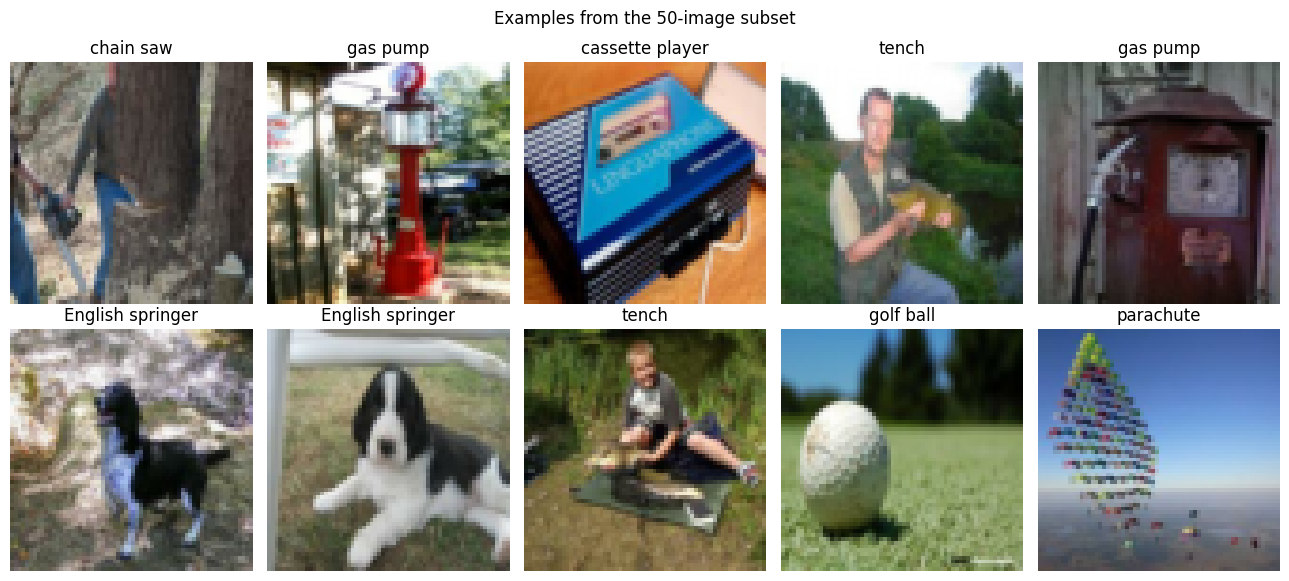

In [33]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, image, label in zip(axes.ravel(), images[:10], labels[:10]):
    ax.imshow(tf.cast(image, tf.uint8))
    ax.set_title(class_names[int(label)])
    ax.axis("off")
plt.suptitle("Examples from the 500-image subset")
plt.tight_layout()
plt.show()


## 6. Identical augmentation for both models

With only 350 training images, memorization is easy. During training, both
models receive the same types of random changes. Augmentation creates varied
views but does not add new labeled objects.


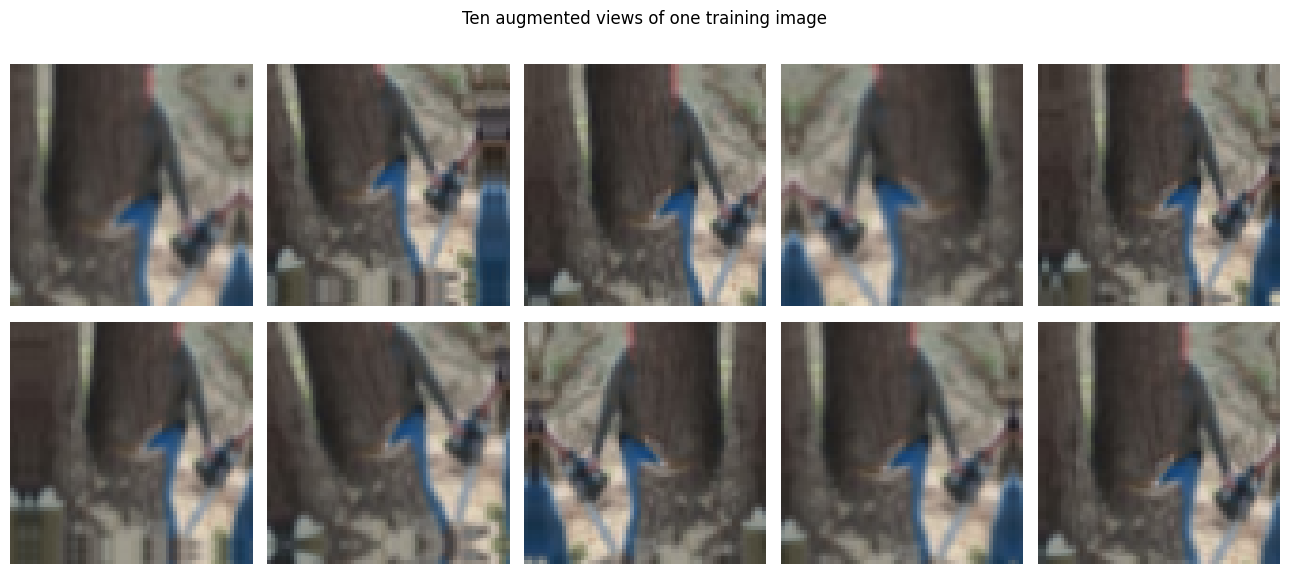

In [34]:
def make_augmentation():
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal", seed=SEED),
            tf.keras.layers.RandomRotation(0.05, seed=SEED + 1),
            tf.keras.layers.RandomZoom(0.10, seed=SEED + 2),
            tf.keras.layers.RandomTranslation(0.08, 0.08, seed=SEED + 3),
        ],
        name="augmentation",
    )


fig, axes = plt.subplots(2, 5, figsize=(13, 6))
example = images[0:1]
preview_augmentation = make_augmentation()
for ax in axes.ravel():
    augmented = preview_augmentation(example, training=True)[0]
    ax.imshow(tf.cast(tf.clip_by_value(augmented, 0, 255), tf.uint8))
    ax.axis("off")
plt.suptitle("Ten augmented views of one training image")
plt.tight_layout()
plt.show()


## 7. Model A: fully connected NN

The fully connected model converts the image into a vector:

$$
64\times64\times3=12{,}288\text{ input values}.
$$

The first dense layer alone contains

$$
12{,}288\times128+128=1{,}572{,}992\text{ parameters}.
$$

Flattening does not destroy pixel values, but it removes the explicit 2D
neighborhood organization. A feature learned at one position has different
weights from the same feature at another position.


In [35]:
def build_dense_nn():
    return tf.keras.Sequential(
        [
            tf.keras.layers.Input((IMAGE_SIZE, IMAGE_SIZE, 3)),
            make_augmentation(),
            tf.keras.layers.Rescaling(1.0 / 255),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(0.35),
            tf.keras.layers.Dense(10, activation="softmax"),
        ],
        name="fully_connected_nn",
    )


dense_model = build_dense_nn()
dense_model.summary()


Model: "fully_connected_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,574,282 (6.01 MB)

 Trainable params: 1,574,282 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Model B: convolutional neural network

The CNN keeps the image as a grid. A small kernel detects a local pattern and
uses the same weights at every position.

For a `3 x 3` RGB kernel with 32 output channels:

$$
3\times3\times3\times32+32=896\text{ parameters}.
$$

Pooling and global average pooling reduce spatial dimensions before the final
classifier. This gives the model an image-appropriate inductive bias and far
fewer parameters than flattening into a large dense layer.


In [36]:
def build_cnn():
    inputs = tf.keras.layers.Input((IMAGE_SIZE, IMAGE_SIZE, 3))
    x = make_augmentation()(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2")(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu", name="conv3")(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(10, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs, name="convolutional_nn")


cnn_model = build_cnn()
cnn_model.summary()


Model: "convolutional_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,154 (399.04 KB)

 Trainable params: 102,154 (399.04 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Parameter-count comparison

Parameters are values learned from data. With only 350 training images, a model
with millions of parameters has many opportunities to memorize the training
set. Parameter count alone does not determine quality, but it exposes an
important efficiency difference.


Dense NN parameters: 1,574,282
CNN parameters:      102,154
Dense/CNN ratio:     15.4x


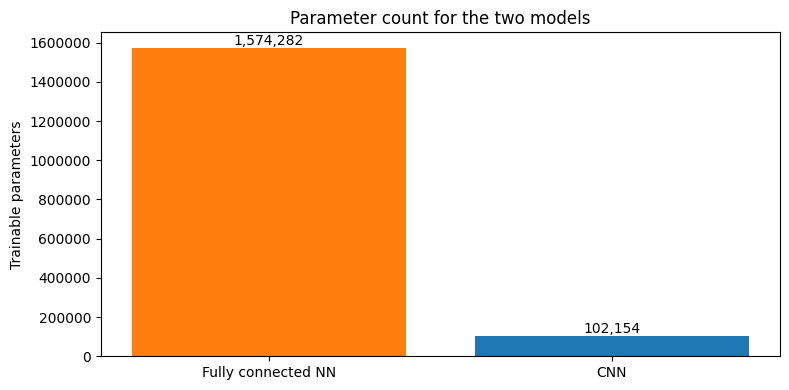

In [37]:
dense_parameters = dense_model.count_params()
cnn_parameters = cnn_model.count_params()
ratio = dense_parameters / cnn_parameters

print(f"Dense NN parameters: {dense_parameters:,}")
print(f"CNN parameters:      {cnn_parameters:,}")
print(f"Dense/CNN ratio:     {ratio:.1f}x")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(["Fully connected NN", "CNN"], [dense_parameters, cnn_parameters],
              color=["tab:orange", "tab:blue"])
ax.set_ylabel("Trainable parameters")
ax.set_title("Parameter count for the two models")
ax.ticklabel_format(axis="y", style="plain")
for bar, value in zip(bars, [dense_parameters, cnn_parameters]):
    ax.text(bar.get_x() + bar.get_width()/2, value, f"{value:,}",
            ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 10. Train both models under the same rules

Both models use Adam, sparse categorical cross-entropy, and early stopping.
The checkpoint with the lowest validation loss is restored.


In [39]:
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )


def train_model(model, label):
    compile_model(model)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True,
            verbose=1,
        )
    ]
    start = time.perf_counter()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=2,
    )
    seconds = time.perf_counter() - start
    print(f"{label} training time: {seconds:.1f} seconds")
    return history, seconds


In [40]:
print("Training the fully connected NN")
dense_history, dense_seconds = train_model(dense_model, "Dense NN")


Training the fully connected NN
Epoch 1/35
22/22 - 2s - 87ms/step - accuracy: 0.0886 - loss: 6.4327 - val_accuracy: 0.1500 - val_loss: 2.2964
Epoch 2/35
22/22 - 1s - 38ms/step - accuracy: 0.1000 - loss: 2.2892 - val_accuracy: 0.1600 - val_loss: 2.2927
Epoch 3/35
22/22 - 1s - 39ms/step - accuracy: 0.1514 - loss: 2.2705 - val_accuracy: 0.1400 - val_loss: 2.2949
Epoch 4/35
22/22 - 1s - 41ms/step - accuracy: 0.1286 - loss: 2.2852 - val_accuracy: 0.1500 - val_loss: 2.2834
Epoch 5/35
22/22 - 1s - 33ms/step - accuracy: 0.1171 - loss: 2.2885 - val_accuracy: 0.0900 - val_loss: 2.3044
Epoch 6/35
22/22 - 0s - 21ms/step - accuracy: 0.1200 - loss: 2.2879 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/35
22/22 - 0s - 22ms/step - accuracy: 0.1000 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/35
22/22 - 1s - 28ms/step - accuracy: 0.1000 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 9/35
22/22 - 0s - 21ms/step - accuracy: 0.1000 - loss: 2.3028 - val_accuracy: 0.10

In [41]:
print("Training the CNN")
cnn_history, cnn_seconds = train_model(cnn_model, "CNN")


Training the CNN
Epoch 1/35
22/22 - 4s - 175ms/step - accuracy: 0.0771 - loss: 2.3073 - val_accuracy: 0.1000 - val_loss: 2.2968
Epoch 2/35
22/22 - 1s - 26ms/step - accuracy: 0.1057 - loss: 2.2917 - val_accuracy: 0.1400 - val_loss: 2.2851
Epoch 3/35
22/22 - 1s - 24ms/step - accuracy: 0.1171 - loss: 2.2927 - val_accuracy: 0.1400 - val_loss: 2.2496
Epoch 4/35
22/22 - 1s - 24ms/step - accuracy: 0.1400 - loss: 2.2371 - val_accuracy: 0.1500 - val_loss: 2.1900
Epoch 5/35
22/22 - 1s - 24ms/step - accuracy: 0.1543 - loss: 2.2050 - val_accuracy: 0.1900 - val_loss: 2.2016
Epoch 6/35
22/22 - 1s - 26ms/step - accuracy: 0.1771 - loss: 2.1795 - val_accuracy: 0.1600 - val_loss: 2.1649
Epoch 7/35
22/22 - 1s - 25ms/step - accuracy: 0.1914 - loss: 2.1893 - val_accuracy: 0.2300 - val_loss: 2.1818
Epoch 8/35
22/22 - 1s - 27ms/step - accuracy: 0.1543 - loss: 2.2126 - val_accuracy: 0.2000 - val_loss: 2.1712
Epoch 9/35
22/22 - 1s - 24ms/step - accuracy: 0.1886 - loss: 2.1323 - val_accuracy: 0.1400 - val_loss:

## 11. Learning curves and overfitting

Look for the **generalization gap** between training and validation accuracy.
With a tiny dataset, results vary by seed, and either model can overfit. The
comparison is more useful than one isolated accuracy number.


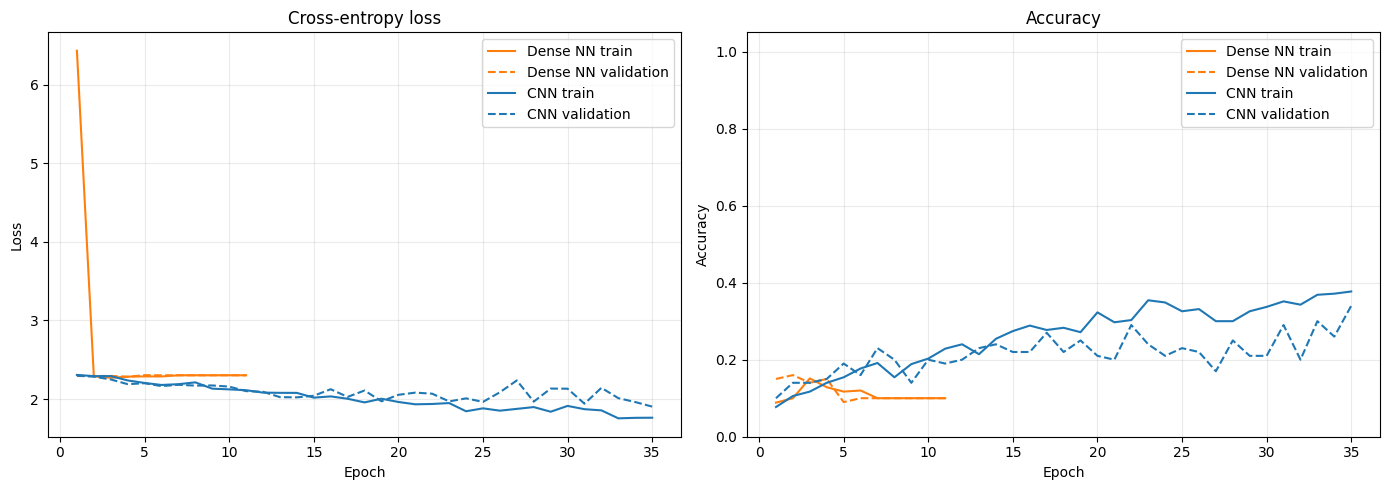

In [42]:
def plot_history(ax_loss, ax_accuracy, history, label, color):
    epochs = np.arange(1, len(history.history["loss"]) + 1)
    ax_loss.plot(epochs, history.history["loss"], color=color, label=f"{label} train")
    ax_loss.plot(epochs, history.history["val_loss"], color=color,
                 linestyle="--", label=f"{label} validation")
    ax_accuracy.plot(epochs, history.history["accuracy"], color=color,
                     label=f"{label} train")
    ax_accuracy.plot(epochs, history.history["val_accuracy"], color=color,
                     linestyle="--", label=f"{label} validation")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_history(axes[0], axes[1], dense_history, "Dense NN", "tab:orange")
plot_history(axes[0], axes[1], cnn_history, "CNN", "tab:blue")

axes[0].set_title("Cross-entropy loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 12. Evaluate the untouched test set

The test set has 50 images, five per class. Report the raw number correct along
with accuracy. Do not overinterpret a difference of one or two images.


In [43]:
def collect_labels(dataset):
    return np.concatenate([labels.numpy() for _, labels in dataset])


y_test = collect_labels(test_ds)
dense_probabilities = dense_model.predict(test_ds, verbose=0)
cnn_probabilities = cnn_model.predict(test_ds, verbose=0)
dense_predictions = dense_probabilities.argmax(axis=1)
cnn_predictions = cnn_probabilities.argmax(axis=1)

dense_correct = int(np.sum(dense_predictions == y_test))
cnn_correct = int(np.sum(cnn_predictions == y_test))

dense_test_loss, dense_test_accuracy = dense_model.evaluate(test_ds, verbose=0)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_ds, verbose=0)

print(f"Dense NN: {dense_correct}/{len(y_test)} correct, accuracy={dense_test_accuracy:.3f}, loss={dense_test_loss:.3f}")
print(f"CNN:      {cnn_correct}/{len(y_test)} correct, accuracy={cnn_test_accuracy:.3f}, loss={cnn_test_loss:.3f}")


Dense NN: 7/20 correct, accuracy=0.140, loss=2.290
CNN:      16/20 correct, accuracy=0.320, loss=1.963


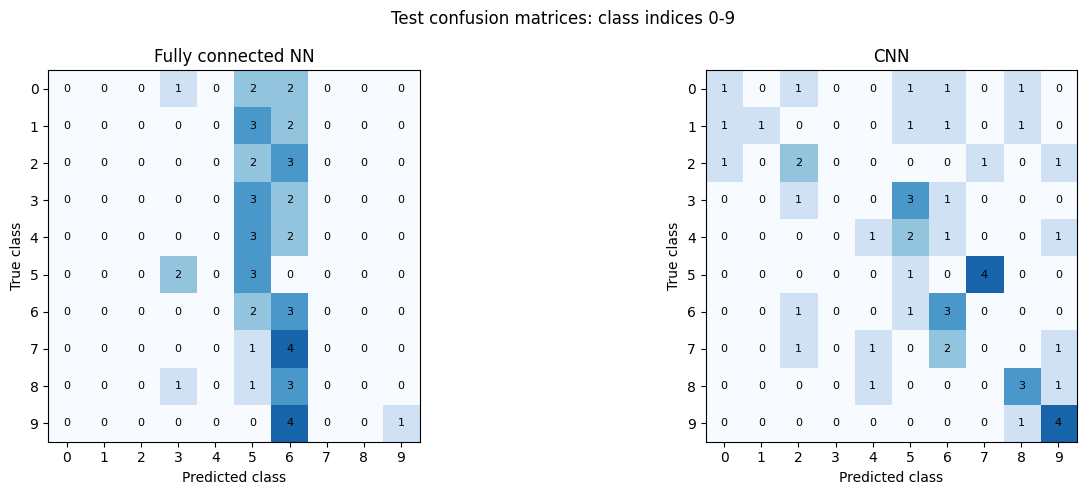

Class index mapping:
0 tench
1 English springer
2 cassette player
3 chain saw
4 church
5 French horn
6 garbage truck
7 gas pump
8 golf ball
9 parachute


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, predictions, title in [
    (axes[0], dense_predictions, "Fully connected NN"),
    (axes[1], cnn_predictions, "CNN"),
]:
    matrix = confusion_matrix(y_test, predictions, labels=np.arange(10))
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=TEST_PER_CLASS)
    for row in range(10):
        for col in range(10):
            ax.text(col, row, matrix[row, col], ha="center", va="center", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
plt.suptitle("Test confusion matrices: class indices 0-9")
plt.tight_layout()
plt.show()

print("Class index mapping:")
for index, name in enumerate(class_names):
    print(index, name)


## 13. Compare predictions image by image

Green titles indicate correct predictions. Red titles indicate mistakes. Look
for cases where the CNN succeeds and the dense model fails, then inspect the
object position, background, texture, and scale.


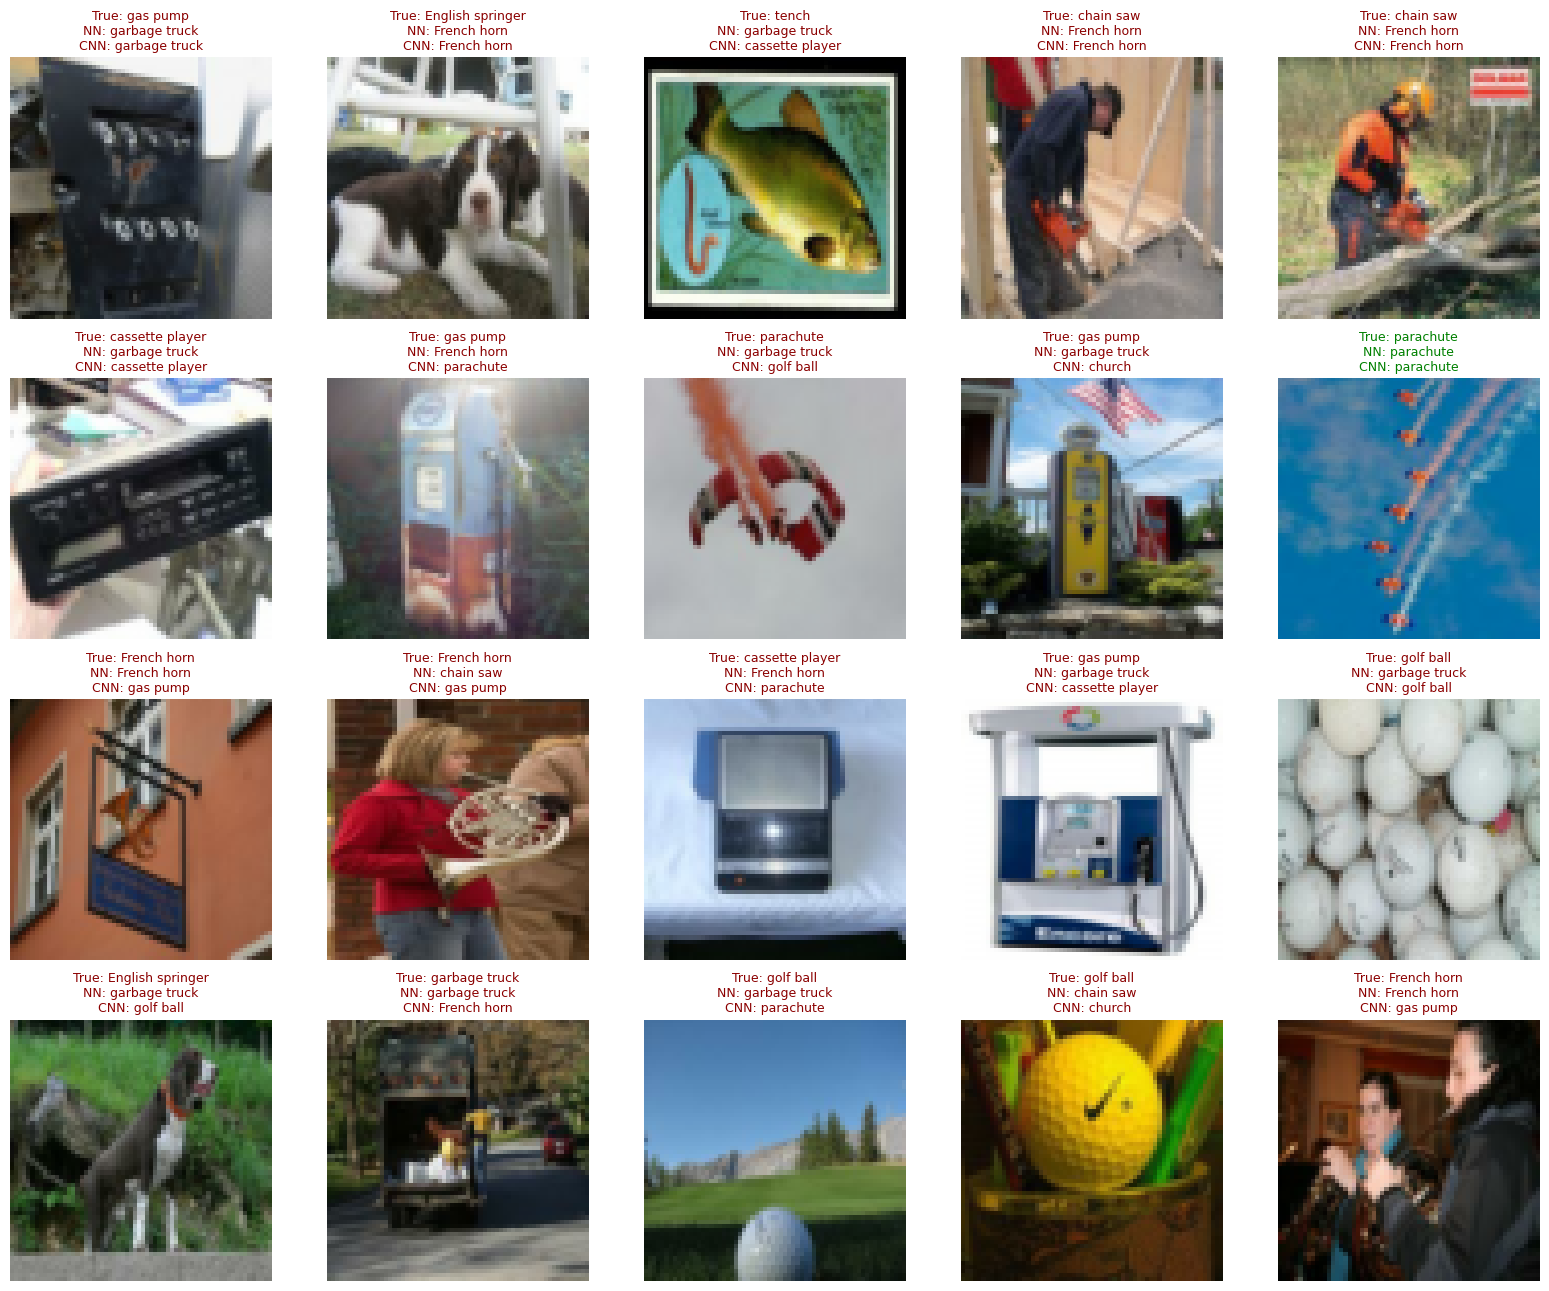

In [45]:
test_images = np.concatenate([batch.numpy() for batch, _ in test_ds])

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
for index, ax in enumerate(axes.ravel()):
    true_name = class_names[y_test[index]]
    dense_name = class_names[dense_predictions[index]]
    cnn_name = class_names[cnn_predictions[index]]
    both_correct = dense_predictions[index] == y_test[index] and cnn_predictions[index] == y_test[index]
    ax.imshow(test_images[index].astype(np.uint8))
    ax.set_title(
        f"True: {true_name}\nNN: {dense_name}\nCNN: {cnn_name}",
        color="green" if both_correct else "darkred",
        fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 14. Translation test

Objects may move within an image. A dense model gives each pixel location its
own weights, while convolution reuses detectors across locations. Pooling also
provides limited tolerance to small shifts.

We shift every test image four pixels to the right and fill the new region with
zeros. This is not perfect translation invariance, but it is a useful stress
test.


In [ ]:
def shift_right(images, pixels=4):
    shifted = np.zeros_like(images)
    shifted[:, :, pixels:, :] = images[:, :, :-pixels, :]
    return shifted


shifted_test_images = shift_right(test_images, pixels=4)
shifted_ds = tf.data.Dataset.from_tensor_slices((shifted_test_images, y_test)).batch(BATCH_SIZE)

dense_shift_accuracy = dense_model.evaluate(shifted_ds, verbose=0)[1]
cnn_shift_accuracy = cnn_model.evaluate(shifted_ds, verbose=0)[1]

print(f"Dense NN clean accuracy:   {dense_test_accuracy:.3f}")
print(f"Dense NN shifted accuracy: {dense_shift_accuracy:.3f}")
print(f"CNN clean accuracy:        {cnn_test_accuracy:.3f}")
print(f"CNN shifted accuracy:      {cnn_shift_accuracy:.3f}")

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for index in range(5):
    axes[0, index].imshow(test_images[index].astype(np.uint8))
    axes[0, index].set_title("Original")
    axes[1, index].imshow(shifted_test_images[index].astype(np.uint8))
    axes[1, index].set_title("Shifted right")
    axes[0, index].axis("off")
    axes[1, index].axis("off")
plt.tight_layout()
plt.show()


## 15. Inspect CNN feature maps

The first convolutional layer produces 32 spatial feature maps. Each map shows
where one learned kernel responds strongly. Early kernels often react to
oriented edges, colors, and simple textures.

The fully connected model has hidden activations, but after flattening they no
longer form an explicit spatial map.


In [ ]:
feature_model = tf.keras.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer("conv1").output,
)

sample_image = test_images[0:1]
feature_maps = feature_model.predict(sample_image, verbose=0)[0]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for channel, ax in enumerate(axes.ravel()):
    ax.imshow(feature_maps[:, :, channel], cmap="viridis")
    ax.set_title(f"Feature map {channel}")
    ax.axis("off")
plt.suptitle(f"First-layer CNN responses for: {class_names[y_test[0]]}")
plt.tight_layout()
plt.show()


## 16. What this experiment demonstrates

### Fully connected NN

- Treats each pixel location as a separate input feature.
- Uses many parameters after flattening.
- Does not explicitly encode local neighborhoods or reusable patterns.
- Can memorize a tiny training set quickly.

### CNN

- Preserves the image grid.
- Learns local kernels such as edge and texture detectors.
- Reuses each kernel across the image through weight sharing.
- Usually needs fewer parameters and handles spatial changes more naturally.

### Important limitation

With 350 training and 50 test images, measured accuracy has high uncertainty.
The CNN may not win every random run. A stronger conclusion comes from
repeating the experiment with several seeds or increasing the sample to 100
images per class.


## 17. Student investigation

Record results in a table before changing the next variable.

### Experiment A: remove augmentation

1. Replace `make_augmentation()` with an empty sequential model.
2. Retrain both models.
3. Compare training accuracy, validation accuracy, and shifted accuracy.

### Experiment B: change image size

1. Try `IMAGE_SIZE = 32`, `64`, and `96`.
2. Rebuild both models each time.
3. Record parameter counts and training time.
4. Explain why dense parameters grow much faster.

### Experiment C: increase data

1. Set `IMAGES_PER_CLASS = 100`.
2. Use `70/15/15` images per class for train/validation/test.
3. Compare the stability of the confusion matrices.

### Experiment D: remove pooling

1. Remove one CNN max-pooling layer.
2. Inspect feature-map sizes and parameter count.
3. Compare clean and shifted accuracy.


## 18. Short-answer questions

1. Why does the dense NN have many more parameters?
2. What spatial information becomes less explicit after flattening?
3. What does weight sharing mean in a convolutional layer?
4. Why is the CNN not perfectly translation invariant?
5. Why can a model achieve high training accuracy but poor test accuracy here?
6. Why should we report `correct/50` as well as test accuracy?
7. Does one run prove that every CNN is better than every fully connected NN?

<details>
<summary><strong>Reveal concise answers</strong></summary>

1. Every input pixel connects to every dense neuron with a separate weight.
2. The row-column neighborhood and relative spatial arrangement are no longer
   represented as a 2D grid.
3. The same kernel coefficients are applied at every image position.
4. Borders, stride, pooling, and finite receptive fields still affect shifted
   responses.
5. The model can memorize 350 training examples.
6. Each of 50 test images changes accuracy by two percentage points.
7. No. Architecture, data, optimization, regularization, and random variation
   all affect the result.

</details>


## 19. Summary

The comparison isolates the main reason CNNs suit images:

$$
\boxed{\text{local connectivity + weight sharing + spatial feature maps}}
$$

A fully connected network can classify images, but its parameter count grows
rapidly with image resolution, and it must learn similar patterns separately at
different positions. A CNN builds reusable local detectors and combines them
into increasingly meaningful spatial features.

### Dataset references

- [FastAI Imagenette repository](https://github.com/fastai/imagenette)
- [TensorFlow Datasets Imagenette catalog](https://www.tensorflow.org/datasets/catalog/imagenette)
